## 1. Imports and Setup

In [2]:
# ==========================================
# Import Required Libraries
# ==========================================

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning utilities
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Machine Learning models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    auc
)

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# ==========================================
# Project Configuration
# ==========================================

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load the Dataset




In [3]:
# ==========================================
# Load the Dataset
# ==========================================

DATA_PATH = "data/raw/social_media_engagement_dataset.csv"

# Load the dataset
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print(f"Dataset Shape: {df.shape}")

# Display the first five rows
df.head()

Dataset loaded successfully!
Dataset Shape: (5000, 20)


,Post_ID,Timestamp,Platform,Content_Type,Category,Likes,Comments,Shares,Views,Saves,Follower_Count,Engagement_Rate,Hour_of_Day,Day_of_Week,Hashtag_Count,Content_Length,Sentiment,Influencer_Tier,Has_Media,Is_Verified
0,POST_04552,2024-01-01 01:42:00,Instagram,Carousel,Business,8287,247,51,29502,20,223080,3.85,1,Monday,16,985,Positive,Macro,True,False
1,POST_02171,2024-01-01 05:05:00,LinkedIn,Document,Health,1711,27,247,24538,139,312647,0.63,5,Monday,9,627,Negative,Macro,False,True
2,POST_00210,2024-01-01 09:18:00,Instagram,Carousel,Food,1527,191,7,5460,359,220737,0.78,9,Monday,27,79,Positive,Macro,True,True
3,POST_01548,2024-01-01 10:58:00,Facebook,Video,Sports,535,178,433,68246,740,428935,0.27,10,Monday,17,554,Neutral,Macro,True,False
4,POST_01350,2024-01-01 13:12:00,Instagram,Photo,Fitness,9706,35,118,25782,611,64384,15.31,13,Monday,5,1136,Positive,Mid-tier,True,False


## 3. First Look at the Data

In [4]:
# ==========================================
# Dataset Overview
# ==========================================

print("=" * 50)
print("Dataset Shape")
print("=" * 50)
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

print("\n" + "=" * 50)
print("Dataset Information")
print("=" * 50)

df.info()


Dataset Shape
Rows    : 5000
Columns : 20

Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Post_ID          5000 non-null   str    
 1   Timestamp        5000 non-null   str    
 2   Platform         5000 non-null   str    
 3   Content_Type     5000 non-null   str    
 4   Category         5000 non-null   str    
 5   Likes            5000 non-null   int64  
 6   Comments         5000 non-null   int64  
 7   Shares           5000 non-null   int64  
 8   Views            5000 non-null   int64  
 9   Saves            5000 non-null   int64  
 10  Follower_Count   5000 non-null   int64  
 11  Engagement_Rate  5000 non-null   float64
 12  Hour_of_Day      5000 non-null   int64  
 13  Day_of_Week      5000 non-null   str    
 14  Hashtag_Count    5000 non-null   int64  
 15  Content_Length   5000 non-null   int64  
 16  Sentimen

In [5]:
# ==========================================
# Statistical Summary of the Dataset
# ==========================================

display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Post_ID,5000,5000,POST_04552,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Timestamp,5000,4985,2024-01-12 20:49:00,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Platform,5000,6,Instagram,1283,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Content_Type,5000,17,Video,616,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,5000,12,Gaming,476,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Likes,5000.0,NaN,NaN,NaN,7536.8384,10169.129568,18.0,1707.75,4073.5,7783.0,49949.0
Comments,5000.0,NaN,NaN,NaN,339.8988,399.813585,1.0,96.0,212.0,377.0,1999.0
Shares,5000.0,NaN,NaN,NaN,835.2334,1013.769853,2.0,177.0,427.5,1111.5,4997.0
Views,5000.0,NaN,NaN,NaN,110968.397,181287.350216,527.0,18506.75,40663.5,84226.75,999256.0
Saves,5000.0,NaN,NaN,NaN,753.1506,932.653475,5.0,200.0,424.0,805.0,4985.0


## 4. Data Cleaning Checks



In [6]:
# ==========================================
# Data Cleaning Checks
# ==========================================

# Check for missing values
missing_values = df.isnull().sum()

print("=" * 50)
print("Missing Value Analysis")
print("=" * 50)

if missing_values.sum() == 0:
    print("No missing values found in the dataset.")
else:
    print(missing_values[missing_values > 0])

# Check for duplicate rows
duplicate_rows = df.duplicated().sum()

print("\n" + "=" * 50)
print("Duplicate Row Analysis")
print("=" * 50)
print(f"Duplicate Rows: {duplicate_rows}")


Missing Value Analysis
No missing values found in the dataset.

Duplicate Row Analysis
Duplicate Rows: 0


### Observations

- The dataset contains no missing values.
- No duplicate records were found.
- No data cleaning was required at this stage.
- The dataset is ready for exploratory data analysis (EDA).

## 5. Exploratory Data Analysis (EDA)

### 5.1 Distribution of Engagement Rate

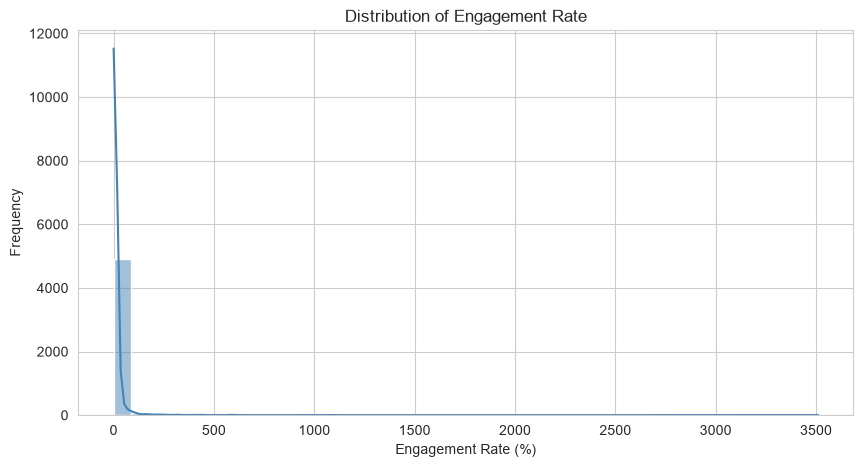

Summary Statistics for Engagement Rate


count    5000.000000
mean       11.960148
std        71.462053
min         0.050000
25%         1.030000
50%         2.300000
75%         6.245000
max      3510.460000
Name: Engagement_Rate, dtype: float64

In [7]:
# ==========================================
# Distribution of Engagement Rate
# ==========================================

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Engagement_Rate",
    bins=40,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Engagement Rate")
plt.xlabel("Engagement Rate (%)")
plt.ylabel("Frequency")

plt.show()

print("=" * 50)
print("Summary Statistics for Engagement Rate")
print("=" * 50)

display(df["Engagement_Rate"].describe())



### Observation

The Engagement Rate distribution is highly right-skewed, with most posts having relatively low engagement rates and a few posts exhibiting extremely high values. These outliers will be considered during target creation and model development.

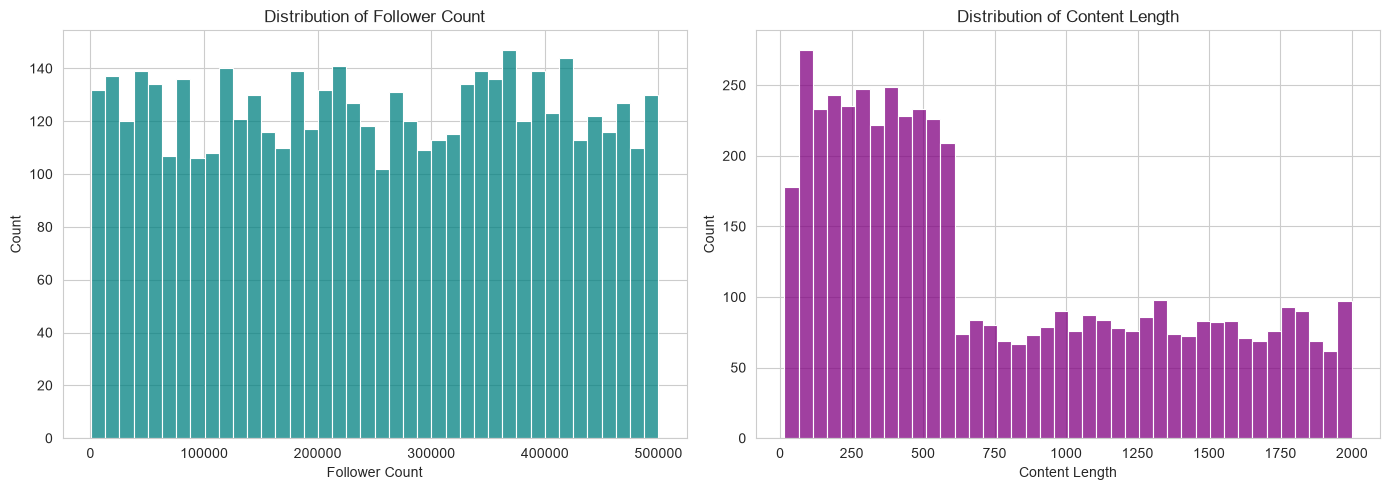

In [8]:
# ==========================================
# Numerical Feature Distributions
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Follower Count Distribution
sns.histplot(
    data=df,
    x="Follower_Count",
    bins=40,
    color="teal",
    ax=axes[0]
)

axes[0].set_title("Distribution of Follower Count")
axes[0].set_xlabel("Follower Count")

# Content Length Distribution
sns.histplot(
    data=df,
    x="Content_Length",
    bins=40,
    color="purple",
    ax=axes[1]
)

axes[1].set_title("Distribution of Content Length")
axes[1].set_xlabel("Content Length")

plt.tight_layout()
plt.show()

### Observations

- Follower Count is fairly evenly distributed across the dataset with no obvious extreme skewness.
- Content Length shows greater variation, with most posts having shorter content and fewer posts containing very long content.
- Both features appear suitable for further preprocessing and model training.

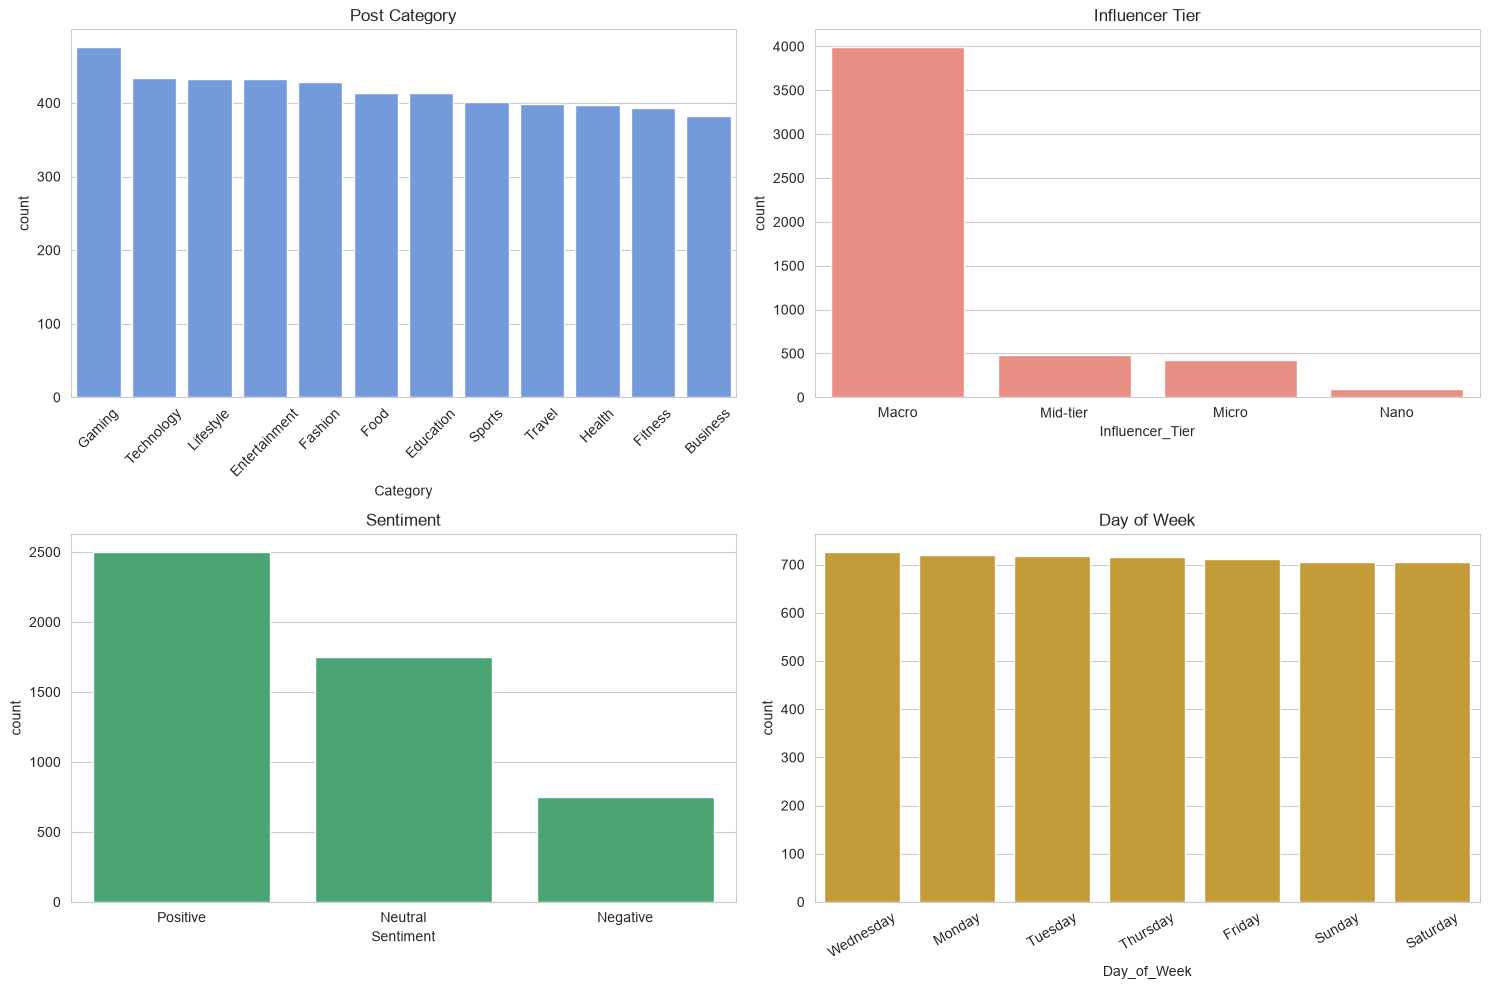

In [9]:
# ==========================================
# Categorical Feature Distributions
# ==========================================

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Category
sns.countplot(
    data=df,
    x="Category",
    order=df["Category"].value_counts().index,
    ax=axes[0, 0],
    color="cornflowerblue"
)
axes[0, 0].set_title("Post Category")
axes[0, 0].tick_params(axis="x", rotation=45)

# Influencer Tier
sns.countplot(
    data=df,
    x="Influencer_Tier",
    order=df["Influencer_Tier"].value_counts().index,
    ax=axes[0, 1],
    color="salmon"
)
axes[0, 1].set_title("Influencer Tier")

# Sentiment
sns.countplot(
    data=df,
    x="Sentiment",
    order=df["Sentiment"].value_counts().index,
    ax=axes[1, 0],
    color="mediumseagreen"
)
axes[1, 0].set_title("Sentiment")

# Day of Week
sns.countplot(
    data=df,
    x="Day_of_Week",
    order=df["Day_of_Week"].value_counts().index,
    ax=axes[1, 1],
    color="goldenrod"
)
axes[1, 1].set_title("Day of Week")
axes[1, 1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

### Observations

- Post categories are well balanced across the dataset.
- Influencer Tier is highly imbalanced, with most posts coming from Macro influencers.
- Positive sentiment is the most common, followed by Neutral and Negative.
- Posts are distributed almost uniformly across all days of the week, indicating no obvious temporal sampling bias.

### 5.4 Correlation between numeric features

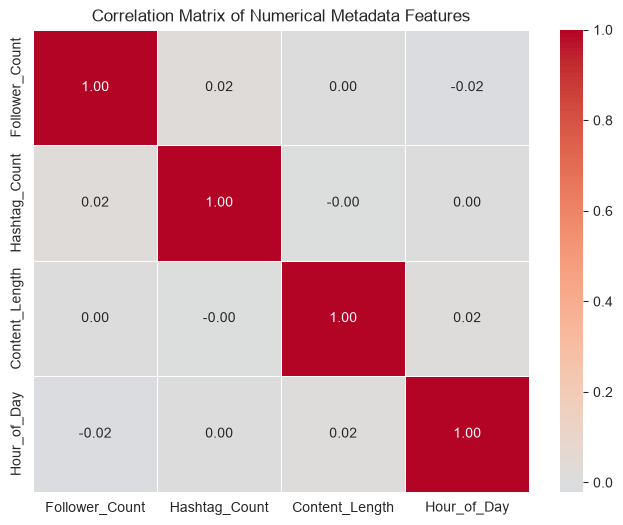

In [10]:
# ==========================================
# Correlation Between Numerical Metadata Features
# ==========================================

numeric_cols = [
    "Follower_Count",
    "Hashtag_Count",
    "Content_Length",
    "Hour_of_Day"
]

plt.figure(figsize=(8, 6))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    center=0
)

plt.title("Correlation Matrix of Numerical Metadata Features")

plt.show()

### Observations

- The numerical metadata features show very weak pairwise correlations.
- No significant multicollinearity is observed.
- Therefore, all numerical metadata features will be retained for further preprocessing and model training.

## 6. Creating the Target Variable

The original target (`Engagement_Rate`) is a continuous variable.  
Based on the exploratory data analysis, the distribution is highly right-skewed with:
- Q1 ≈ 1.03%
- Median ≈ 2.30%
- Q3 ≈ 6.25%

To create a meaningful classification problem, we define practical engagement levels using thresholds of **2%** and **6%**, which closely align with the observed distribution while remaining easy to interpret.


Target Class Distribution
Engagement_Class
Low       2287
Medium    1420
High      1293
Name: count, dtype: int64


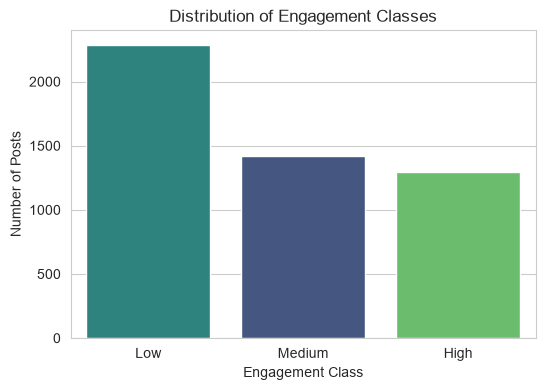

In [11]:
# ==========================================
# Create Target Variable
# ==========================================

LOW_CUTOFF = 2.0
HIGH_CUTOFF = 6.0


def classify_engagement(rate):
    if rate < LOW_CUTOFF:
        return "Low"
    elif rate < HIGH_CUTOFF:
        return "Medium"
    else:
        return "High"


# Create target variable
df["Engagement_Class"] = df["Engagement_Rate"].apply(classify_engagement)

# Display class distribution
class_counts = (
    df["Engagement_Class"]
    .value_counts()
    .reindex(["Low", "Medium", "High"])
)

print("=" * 40)
print("Target Class Distribution")
print("=" * 40)
print(class_counts)

# Visualize class distribution
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="Engagement_Class",
    order=["Low", "Medium", "High"],
    hue="Engagement_Class",
    palette="viridis",
    legend=False
)

plt.title("Distribution of Engagement Classes")
plt.xlabel("Engagement Class")
plt.ylabel("Number of Posts")

plt.show()

### Observations

- The continuous Engagement Rate was converted into three classes:
  - **Low** (< 2%)
  - **Medium** (2% to 6%)
  - **High** (> 6%)
- The resulting class distribution is reasonably balanced, with Low engagement being the most common.
- This distribution is suitable for multi-class classification without requiring any immediate resampling techniques.

## 7. Removing Leakage and Irrelevant Columns

To build a realistic prediction model, we remove columns that would not be available before a post is published.

The following columns are removed:

- **Likes, Comments, Shares, Views, Saves:** These are post-publication engagement metrics and would cause data leakage.
- **Engagement_Rate:** This was used to create the target variable (`Engagement_Class`).
- **Post_ID:** A unique identifier with no predictive value.

In [12]:
# ==========================================
# Remove Leakage and Irrelevant Columns
# ==========================================

# Columns that introduce data leakage
leakage_columns = [
    "Likes",
    "Comments",
    "Shares",
    "Views",
    "Saves",
    "Engagement_Rate"
]

# Identifier column
id_columns = ["Post_ID"]

# Create the final modeling dataset
df_model = df.drop(columns=leakage_columns + id_columns)

print("Remaining Features")
print("-" * 30)
print(df_model.columns.tolist())

print(f"\nFinal Dataset Shape: {df_model.shape}")

Remaining Features
------------------------------
['Timestamp', 'Platform', 'Content_Type', 'Category', 'Follower_Count', 'Hour_of_Day', 'Day_of_Week', 'Hashtag_Count', 'Content_Length', 'Sentiment', 'Influencer_Tier', 'Has_Media', 'Is_Verified', 'Engagement_Class']

Final Dataset Shape: (5000, 14)


### Observations

- Post-publication engagement metrics were removed to prevent data leakage.
- The identifier column (`Post_ID`) was removed because it carries no predictive information.
- The remaining dataset consists only of metadata that would be available before a post is published.

## 8. Feature Engineering



In [13]:
# ==========================================
# Feature Engineering
# ==========================================


df_model = df_model.drop(columns=["Timestamp"])

# Number of hashtags per 100 characters
df_model["Hashtag_Density"] = (
    df_model["Hashtag_Count"] /
    (df_model["Content_Length"] / 100)
)

# Weekend indicator
df_model["Is_Weekend"] = (
    df_model["Day_of_Week"]
    .isin(["Saturday", "Sunday"])
    .astype(int)
)

# Group posting time into broader time periods
def time_bucket(hour):
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"

df_model["Time_Bucket"] = df_model["Hour_of_Day"].apply(time_bucket)

# Preview engineered features
df_model[
    [
        "Hashtag_Count",
        "Content_Length",
        "Hashtag_Density",
        "Day_of_Week",
        "Is_Weekend",
        "Hour_of_Day",
        "Time_Bucket",
    ]
].head()

,Hashtag_Count,Content_Length,Hashtag_Density,Day_of_Week,Is_Weekend,Hour_of_Day,Time_Bucket
0,16,985,1.624365,Monday,0,1,Night
1,9,627,1.435407,Monday,0,5,Morning
2,27,79,34.177215,Monday,0,9,Morning
3,17,554,3.068592,Monday,0,10,Morning
4,5,1136,0.440141,Monday,0,13,Afternoon


### Feature Engineering Summary

The following features were engineered to provide additional predictive information:

- **Hashtag_Density:** Measures hashtag usage relative to content length.
- **Is_Weekend:** Indicates whether the post was published on a weekend.
- **Time_Bucket:** Groups posting hours into Morning, Afternoon, Evening, and Night to capture broader temporal patterns.

These engineered features are derived only from information available before publication and therefore do not introduce data leakage.

## 9. Encoding and Scaling

- **Ordinal encoding** for `Influencer_Tier` it has a real order (Nano < Micro < Mid-tier <
  Macro), so we encode it as 0/1/2/3 instead of one-hot, to preserve that ordering.
- **One-hot encoding** for the remaining categorical columns (`Category`, `Sentiment`,
  `Day_of_Week`, `Time_Bucket`) — these have no natural order.
- **Standard scaling** applied to numerical features because it is important for Logistic Regression. Tree-based models such as Random Forest and XGBoost do not require feature scaling, but using a common preprocessing pipeline simplifies model comparison.


In [14]:
# ==========================================
# Encoding and Scaling
# ==========================================

# Ordinal encoding for Influencer Tier
tier_order = {
    "Nano": 0,
    "Micro": 1,
    "Mid-tier": 2,
    "Macro": 3
}

df_model["Influencer_Tier_Encoded"] = (
    df_model["Influencer_Tier"].map(tier_order)
)

# Convert boolean columns to integers
df_model["Is_Verified"] = df_model["Is_Verified"].astype(int)
df_model["Has_Media"] = df_model["Has_Media"].astype(int)

# Numerical features
numeric_features = [
    "Follower_Count",
    "Hashtag_Count",
    "Content_Length",
    "Hashtag_Density",
    "Hour_of_Day",
    "Influencer_Tier_Encoded",
    "Is_Verified",
    "Has_Media",
    "Is_Weekend",
]

# Categorical features
categorical_features = [
    "Platform",
    "Content_Type",
    "Category",
    "Sentiment",
    "Day_of_Week",
    "Time_Bucket",
]

# Feature matrix and target
X = df_model[numeric_features + categorical_features]
y = df_model["Engagement_Class"]

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

print(f"Feature Matrix Shape: {X.shape}")
display(X.head())

print(f"Numerical Features   : {len(numeric_features)}")
print(f"Categorical Features : {len(categorical_features)}")

Feature Matrix Shape: (5000, 15)


,Follower_Count,Hashtag_Count,Content_Length,Hashtag_Density,Hour_of_Day,Influencer_Tier_Encoded,Is_Verified,Has_Media,Is_Weekend,Platform,Content_Type,Category,Sentiment,Day_of_Week,Time_Bucket
0,223080,16,985,1.624365,1,3,0,1,0,Instagram,Carousel,Business,Positive,Monday,Night
1,312647,9,627,1.435407,5,3,1,0,0,LinkedIn,Document,Health,Negative,Monday,Morning
2,220737,27,79,34.177215,9,3,1,1,0,Instagram,Carousel,Food,Positive,Monday,Morning
3,428935,17,554,3.068592,10,3,0,1,0,Facebook,Video,Sports,Neutral,Monday,Morning
4,64384,5,1136,0.440141,13,2,0,1,0,Instagram,Photo,Fitness,Positive,Monday,Afternoon


Numerical Features   : 9
Categorical Features : 6


## 10. Train/Test Split

The dataset is divided into training (80%) and testing (20%) sets.

A **stratified split** is used so that the proportions of the three engagement classes (Low, Medium, High) remain approximately the same in both sets. This ensures a fair evaluation and prevents the test set from becoming biased toward a particular class.

In [15]:
# ==========================================
# Train-Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("=" * 40)
print("Dataset Split")
print("=" * 40)
print(f"Training Samples : {X_train.shape[0]}")
print(f"Testing Samples  : {X_test.shape[0]}")

print("\nTraining Class Distribution")
print("-" * 30)
print(y_train.value_counts(normalize=True).sort_index().round(3))

print("\nTesting Class Distribution")
print("-" * 30)
print(y_test.value_counts(normalize=True).sort_index().round(3))

Dataset Split
Training Samples : 4000
Testing Samples  : 1000

Training Class Distribution
------------------------------
Engagement_Class
High      0.258
Low       0.458
Medium    0.284
Name: proportion, dtype: float64

Testing Class Distribution
------------------------------
Engagement_Class
High      0.259
Low       0.457
Medium    0.284
Name: proportion, dtype: float64


### Observations

- The dataset was split into 80% training data and 20% testing data.
- Stratified sampling successfully preserved the class distribution across both sets.
- The training and testing sets closely match the original class proportions, ensuring a fair evaluation of model performance.

## 11. Model Training



In [16]:
# ==========================================
# Model Training
# ==========================================

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.1,
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
        use_label_encoder=False,
        n_jobs=-1
    ),
}

# Encode target labels
label_map = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}

y_train_enc = y_train.map(label_map)
y_test_enc = y_test.map(label_map)

# Train all models
pipelines = {}

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    pipeline.fit(X_train, y_train_enc)

    pipelines[name] = pipeline

    print(f" {name} trained successfully.")

 Logistic Regression trained successfully.
 Random Forest trained successfully.
 XGBoost trained successfully.


## 12. Model Evaluation



In [17]:
# ==========================================
# Model Evaluation
# ==========================================

results = []

for name, pipeline in pipelines.items():

    y_pred = pipeline.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_enc, y_pred),
        "Precision (Macro)": precision_score(
            y_test_enc,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "Recall (Macro)": recall_score(
            y_test_enc,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "F1 Score (Macro)": f1_score(
            y_test_enc,
            y_pred,
            average="macro",
            zero_division=0
        )
    })

results_df = (
    pd.DataFrame(results)
    .sort_values("F1 Score (Macro)", ascending=False)
    .round(3)
    .reset_index(drop=True)
)

display(results_df)

,Model,Accuracy,Precision (Macro),Recall (Macro),F1 Score (Macro)
0,Logistic Regression,0.733,0.725,0.733,0.727
1,XGBoost,0.741,0.722,0.733,0.726
2,Random Forest,0.723,0.705,0.722,0.711


### Model Comparison

The models are compared using Accuracy, Macro Precision, Macro Recall, and Macro F1-score.

Since the target classes are not perfectly balanced, **Macro F1-score** is considered the primary metric because it gives equal importance to each class rather than being dominated by the majority class.

### Results Summary

- Logistic Regression achieved the highest **Macro F1-score**, making it the best overall model for this task.
- XGBoost obtained the highest Accuracy but slightly lower Macro F1, suggesting it performed better on the majority class.
- Random Forest produced the lowest performance among the three models.

Based on the primary evaluation metric (Macro F1-score), Logistic Regression is selected as the final model.

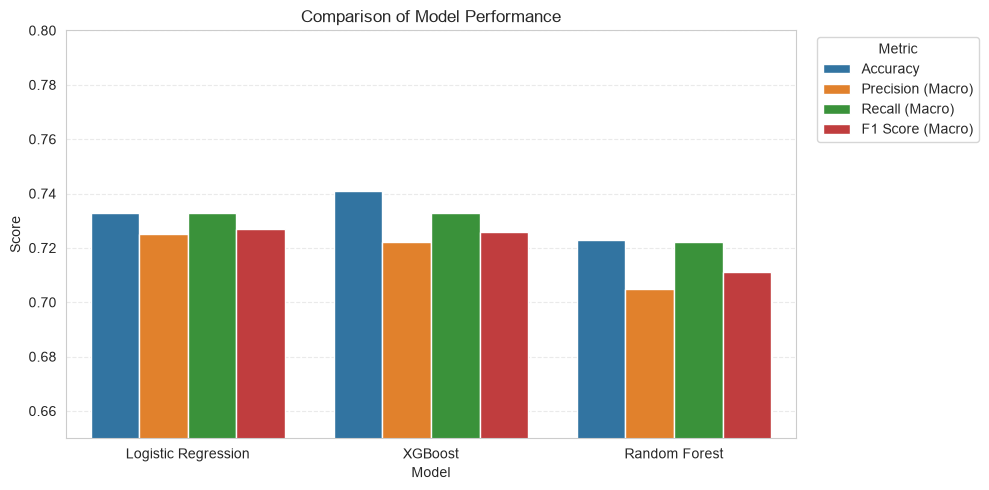

In [18]:
# ==========================================
# Model Performance Comparison
# ==========================================

plt.figure(figsize=(10, 5))

melted = results_df.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

sns.barplot(
    data=melted,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Comparison of Model Performance")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0.65, 0.80)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

plt.show()

### 12.1 Confusion Matrices

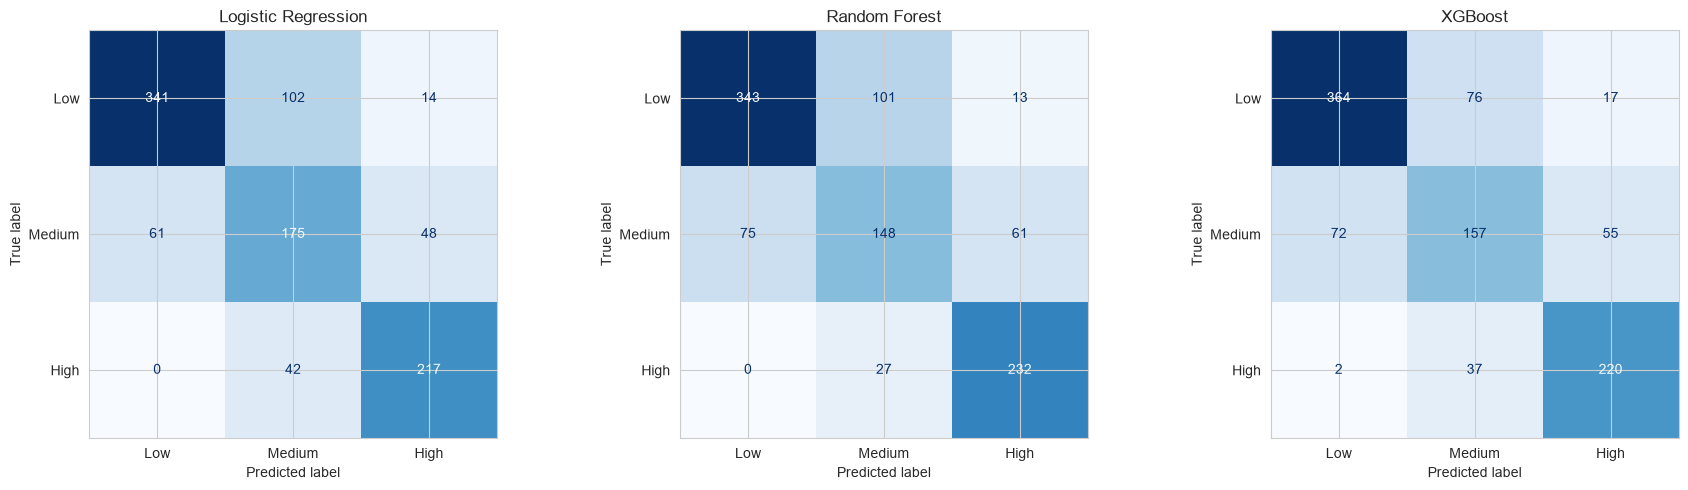

In [19]:
# ==========================================
# Confusion Matrices
# ==========================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

class_names = ["Low", "Medium", "High"]

for ax, (name, pipeline) in zip(axes, pipelines.items()):

    y_pred = pipeline.predict(X_test)

    cm = confusion_matrix(y_test_enc, y_pred)

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    ).plot(
        ax=ax,
        cmap="Blues",
        colorbar=False,
        values_format="d"
    )

    ax.set_title(name)

plt.tight_layout()
plt.show()

### Classification Report Analysis

- Logistic Regression achieved the most balanced performance across all three engagement classes, particularly for the Medium class, resulting in the highest Macro F1-score.
- Random Forest showed the highest recall for High engagement posts but struggled to classify Medium engagement accurately.
- XGBoost performed best on Low engagement posts while maintaining competitive performance on the High class.

Overall, Logistic Regression provided the best balance between Precision, Recall, and F1-score across all classes and was therefore selected as the final model.

In [20]:
# ==========================================
# Classification Reports
# ==========================================

for name, pipeline in pipelines.items():

    y_pred = pipeline.predict(X_test)

    print("=" * 60)
    print(f"{name}")
    print("=" * 60)

    print(
        classification_report(
            y_test_enc,
            y_pred,
            target_names=class_names,
            zero_division=0
        )
    )

Logistic Regression
              precision    recall  f1-score   support

         Low       0.85      0.75      0.79       457
      Medium       0.55      0.62      0.58       284
        High       0.78      0.84      0.81       259

    accuracy                           0.73      1000
   macro avg       0.72      0.73      0.73      1000
weighted avg       0.74      0.73      0.74      1000

Random Forest
              precision    recall  f1-score   support

         Low       0.82      0.75      0.78       457
      Medium       0.54      0.52      0.53       284
        High       0.76      0.90      0.82       259

    accuracy                           0.72      1000
   macro avg       0.70      0.72      0.71      1000
weighted avg       0.72      0.72      0.72      1000

XGBoost
              precision    recall  f1-score   support

         Low       0.83      0.80      0.81       457
      Medium       0.58      0.55      0.57       284
        High       0.75      0.85

## 13. Cross-Validation Sanity Check

A single train/test split can be lucky or unlucky. Running 5-fold cross-validation on the
full training set gives a more reliable estimate of how stable each model's performance is.


In [21]:
# ==========================================
# Cross-Validation
# ==========================================

from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("=" * 60)
print("5-Fold Cross Validation")
print("=" * 60)

for name, pipeline in pipelines.items():

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train_enc,
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1
    )

    print(f"{name}")
    print(f"Mean Macro F1 : {scores.mean():.3f}")
    print(f"Std Dev       : {scores.std():.3f}")
    print("-" * 40)

5-Fold Cross Validation
Logistic Regression
Mean Macro F1 : 0.728
Std Dev       : 0.015
----------------------------------------
Random Forest
Mean Macro F1 : 0.717
Std Dev       : 0.004
----------------------------------------
XGBoost
Mean Macro F1 : 0.717
Std Dev       : 0.012
----------------------------------------


### Cross-Validation Summary

- Logistic Regression achieved the highest average Macro F1-score across the five folds.
- Random Forest showed the lowest variation across folds, indicating very stable performance, although with a lower average score.
- XGBoost remained competitive but achieved a slightly lower average Macro F1 than Logistic Regression.

The cross-validation results confirm that Logistic Regression provides the best balance between performance and generalization for this dataset.

## 14. Feature Importance

Only Random Forest and XGBoost expose feature importances directly (Logistic Regression's
coefficients are less directly comparable once one-hot encoding expands the feature space,
so we skip it here for simplicity).


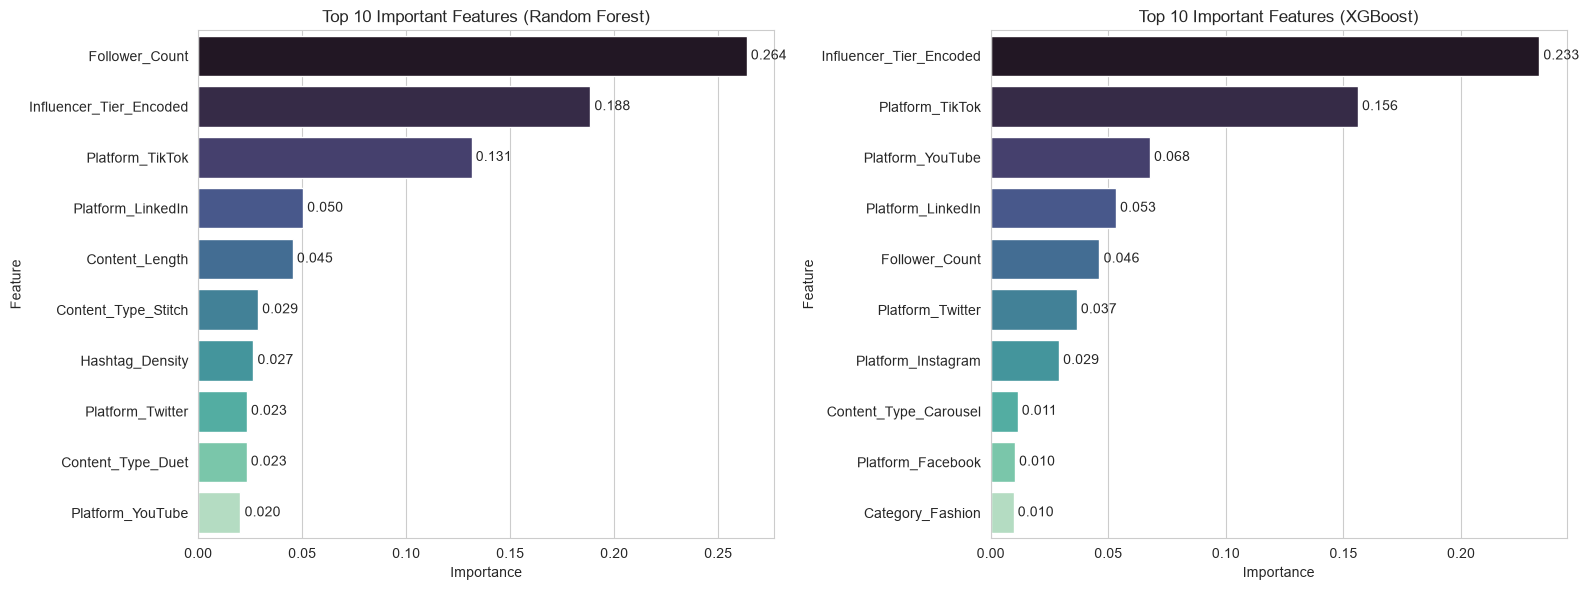

In [22]:
# ==========================================
# Feature Importance
# ==========================================

feature_names = (
    numeric_features +
    list(
        pipelines["Random Forest"]
        .named_steps["preprocessor"]
        .named_transformers_["cat"]
        .get_feature_names_out(categorical_features)
    )
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, model_name in zip(axes, ["Random Forest", "XGBoost"]):

    importances = (
        pipelines[model_name]
        .named_steps["classifier"]
        .feature_importances_
    )

    importance_df = (
        pd.DataFrame({
            "Feature": feature_names,
            "Importance": importances
        })
        .sort_values("Importance", ascending=False)
        .head(10)
    )

    sns.barplot(
        data=importance_df,
        x="Importance",
        y="Feature",
        hue="Feature",
        palette="mako",
        legend=False,
        ax=ax
    )

    ax.set_title(f"Top 10 Important Features ({model_name})")

    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=3)

plt.tight_layout()
plt.show()

### Feature Importance Analysis

The feature importance plots show that both tree-based models rely primarily on creator and platform-related information.

Key observations:

- **Follower_Count** and **Influencer_Tier** are among the most influential features.
- **Platform** plays an important role, indicating that engagement patterns differ across social media platforms.
- The engineered feature **Hashtag_Density** contributes to Random Forest, demonstrating that feature engineering added predictive value.
- Temporal features such as **Is_Weekend** and **Time_Bucket** had relatively low importance compared to creator and platform characteristics.

# 15. Final Model Selection and Conclusions

## Final Model Selection

Three machine learning models were evaluated for predicting social media engagement levels:

- Logistic Regression
- Random Forest
- XGBoost

The comparison was based on Accuracy, Macro Precision, Macro Recall, Macro F1-score, confusion matrices, classification reports, and 5-fold cross-validation.

Although XGBoost achieved the highest test accuracy (74.1%), Logistic Regression obtained the highest Macro F1-score (0.727) and also achieved the best average Macro F1-score during cross-validation (0.728). Since Macro F1 treats all classes equally, it was selected as the primary evaluation metric.

Therefore, **Logistic Regression** was selected as the final model because it provided the best balance between predictive performance and generalization.

---

## Key Findings

- Engagement can be predicted reasonably well using only **pre-publication metadata**.
- Removing post-publication metrics (Likes, Comments, Shares, Views, Saves) successfully prevented data leakage.
- Creator-related features such as **Follower Count** and **Influencer Tier** were the most influential predictors.
- Platform also played an important role, indicating different engagement behaviour across social media platforms.
- The engineered feature **Hashtag Density** contributed to the prediction, demonstrating the value of feature engineering.
- The **Medium** engagement class was consistently the hardest to classify because it overlaps with both Low and High engagement levels.

---

## Limitations

- The target classes were created by converting a continuous Engagement Rate into three discrete categories using fixed thresholds.
- The dataset does not include the actual caption or media content, which are likely to influence engagement.
- Hyperparameter tuning was intentionally kept minimal to focus on building a complete and interpretable machine learning pipeline.

---

## Future Improvements

Future work could include:

- Hyperparameter tuning using GridSearchCV or RandomizedSearchCV.
- Using caption text embeddings with NLP models.
- Incorporating image or video features using computer vision.
- Training on a larger real-world social media dataset.
- Exploring ensemble or stacking methods for improved performance.

---

Overall, this project demonstrates a complete end-to-end machine learning workflow, including data preprocessing, feature engineering, model comparison, evaluation, cross-validation, and model interpretation.

In [23]:
# ==========================================
# Final Model Comparison
# ==========================================

print("=" * 60)
print("FINAL MODEL COMPARISON")
print("=" * 60)

display(results_df)

print("\nSelected Model : Logistic Regression")
print("Reason         : Highest Macro F1-score and best cross-validation performance.")

FINAL MODEL COMPARISON


,Model,Accuracy,Precision (Macro),Recall (Macro),F1 Score (Macro)
0,Logistic Regression,0.733,0.725,0.733,0.727
1,XGBoost,0.741,0.722,0.733,0.726
2,Random Forest,0.723,0.705,0.722,0.711



Selected Model : Logistic Regression
Reason         : Highest Macro F1-score and best cross-validation performance.
